In [2]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import numpy as np

In [3]:

F = 96485  # C.mol-1. It is the Faraday constant.
R = 8.314  # J.mol-1.K-1. It is the universal gas constant.

def Psat(T):
    """This function calculates the saturated partial pressure of vapor, in Pa, as a function of the temperature.

    Parameters
    ----------
    T : float
        Temperature in K.

    Returns
    -------
    float
        Saturated partial pressure of vapor in Pa.
    """
    return 101325 * 10 ** (-2.1794 + 0.02953 * (T - 273.15) - 9.1837e-5 * (T - 273.15) ** 2 +
                           1.4454e-7 * (T - 273.15) ** 3)

In [4]:
def ucell_sw(t):
    t = t%40
    t_stop = 40
    iload_rise =  0.15 * np.tanh(t - t_stop / 4) + 0.3
    iload_drop =  -0.15 * np.tanh(t - t_stop * 3 / 4) +0.3
    return (iload_rise  + iload_drop)

In [5]:
def flourideReleaseRate(MT, U, Tfc, PO2_ca):
    """

    :return:
    """
    # Constant
    A_1 = 1.7e-13  # Fitted constant (ug/(H m-2))
    alpha_eq = 0.6  # Equivalent transfer coefficient
    e_M0 = 2e-5  # The initial membrane thickness (m)
    E_a = 75e3  # The equivalent activation energy (J/mol)
    T0 = 273.15 + 95
    P0 = 1e5

    return A_1 * (PO2_ca/P0) * (e_M0 / MT) * np.exp(alpha_eq * F * U / (R * Tfc)) * np.exp(-E_a / R * (1 / Tfc - 1 / T0))

In [6]:
def dHdt(t, x):
    PO2_ca = 0.21 * 2.5e5 * (1 - 0.75 * Psat(368)/2.5e5)
    return -20.8 / (0.82 * 1980e3) * flourideReleaseRate(MT=x, U=ucell_sw(t), Tfc=368, PO2_ca=PO2_ca)

In [7]:
sol = solve_ivp(fun=dHdt, y0 = [2.5e-5], t_span=(0,3600*200),max_step = 10, method='BDF')

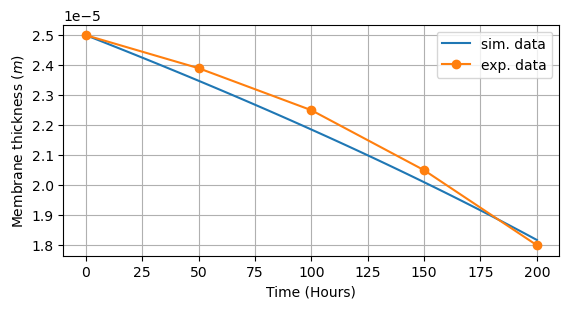

In [8]:
plt.figure(figsize=(6.4,3))
plt.plot(sol.t/3600, sol.y[0,:])
plt.plot([0,50,100,150,200], [2.5e-5,2.39e-5,2.25e-5,2.05e-5,1.8e-5],marker='o')
plt.legend(["sim. data","exp. data"])
plt.ylabel(f"Membrane thickness ($m$)")
plt.xlabel("Time (Hours)")
plt.grid()